In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bruges
import segyio
from fmu.tools import DomainConversion
from scipy.interpolate import interp1d
from bruges import noise

c:\Users\yuril\AppData\Local\Programs\Python\Python313\Lib\site-packages\bruges\__init__.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
import tensorflow as tf
import keras
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, PReLU

In [3]:
import pickle

In [4]:
MODELS_PATH = [r"C:\Users\yuril\Downloads\modelos_105k_512ams_4ms.pkl"]

In [5]:
def read_pickle(file_path: str) -> list:
    pickle_in = open(file_path, "rb")
    data = pickle.load(pickle_in)
    pickle_in.close()
    return data

def split(x):
    top,bottom = np.split(x, 2, axis=0)
    resultado = np.zeros(((x.shape[0])//2,x.shape[1]*2))
    for j in range(x.shape[1]):
        for i in range(x.shape[0]//2):
            resultado[i][j*2] = top[i][j]
            resultado[i][(j*2)-1] = bottom[i][j]
    return resultado

In [6]:
models_outro = []
for path in MODELS_PATH:
    models_outro += read_pickle(path)

In [8]:
for i in range(10000):
    if i == 0 :
        vetor_rc = models_outro[i]['rc']
    else:
        ve = models_outro[i]['rc']
        vetor_rc = np.vstack((vetor_rc,ve))
vetor_rc = vetor_rc.T


In [10]:
for i in range(10000):
    if i == 0 :
        trace = models_outro[i]['trace']
    else:
        tr = models_outro[i]['trace']
        trace = np.vstack((trace,tr))
trace = trace.T

In [12]:
for i in range(10001,15001):
    if i == 10001 :
        vetor_rc_val = models_outro[i]['rc']
    else:
        ve_rc_val = models_outro[i]['rc']
        vetor_rc_val = np.vstack((vetor_rc_val,ve_rc_val))
vetor_rc_val = vetor_rc_val.T

In [13]:
vetor_rc_val.shape

(512, 5000)

In [15]:
for i in range(10001,15001):
    if i == 10001 :
        trace_val = models_outro[i]['trace']
    else:
        tr_val = models_outro[i]['trace']
        trace_val = np.vstack((trace_val,tr_val))
trace_val = trace_val.T

In [16]:
y2 = trace_val

In [17]:
configs = {"modelo":"CNN","activation":"relu","optimizer":"adam","loss":"mse","metrics":"mae"}

In [18]:
X_train = trace
y_train = vetor_rc

if configs["modelo"] == "CNN":
    model = models.Sequential([
        layers.Conv1D(32, 5, activation=configs["activation"], padding='same', input_shape=(512, 1)),
        layers.Conv1D(64, 5, activation=configs["activation"], padding='same'),

        layers.Conv1D(1, 1, activation='linear', padding='same')
    ])

elif configs["modelo"] == "UNet":

    inputs = layers.Input (shape=(512, 10000))

    c1 = layers.Conv1D(32, 5, activation=configs["activation"], padding='same') (inputs)
    p1 = layers.MaxPooling1D(2)(c1)

    c2 = layers.Conv1D(64, 5, activation=configs["activation"], padding='same') (p1)
    p2 = layers.MaxPooling1D(2)(c2)

    c3 = layers.Conv1D(128, 5, activation=configs["activation"], padding='same') (p2)
    p3 = layers.MaxPooling1D(2)(c3)

    b = layers.Conv1D(256, 5, activation=configs["activation"], padding='same') (p3)

    u3 = layers. UpSampling1D(2)(b)
    u3 = layers.concatenate ([u3, c3])
    d3 = layers.Conv1D(128, 5, activation=configs["activation"], padding='same') (u3)

    u2 = layers.UpSampling1D(2)(d3)
    u2 = layers.concatenate ([u2, c2])
    d2 = layers.Conv1D(64, 5, activation=configs["activation"], padding='same') (u2)

    u1 = layers.UpSampling1D(2)(d2)
    u1 = layers.concatenate ([u1, c1])
    d1 = layers.Conv1D(32, 5, activation=configs["activation"], padding='same') (u1)

    outputs = layers.Conv1D(1, 1, activation="linear", padding="same") (d1)

    model = models. Model(inputs, outputs, name="UNet1D")

model.compile(
    optimizer=configs["optimizer"],
    loss=configs["loss"],                 
    metrics=[configs["metrics"]]        
)



c:\Users\yuril\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 512, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 512, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 512, 1)         │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,561 (41.25 KB)

 Trainable params: 10,561 (41.25 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
callback_parada = EarlyStopping(
    monitor='mae', 
    patience=5,
    restore_best_weights=True 
)

In [21]:
history = model.fit(
    X_train,y_train,
    epochs=300, 
    batch_size=32,
    callbacks = [callback_parada],
    validation_split=0.10,
    
)


Epoch 1/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 395ms/step - loss: 0.0065 - mae: 0.0378 - val_loss: 0.0050 - val_mae: 0.0346
Epoch 2/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 343ms/step - loss: 0.0057 - mae: 0.0352 - val_loss: 0.0047 - val_mae: 0.0291
Epoch 3/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 395ms/step - loss: 0.0055 - mae: 0.0330 - val_loss: 0.0046 - val_mae: 0.0271
Epoch 4/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 383ms/step - loss: 0.0054 - mae: 0.0312 - val_loss: 0.0045 - val_mae: 0.0263
Epoch 5/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 400ms/step - loss: 0.0054 - mae: 0.0305 - val_loss: 0.0045 - val_mae: 0.0261
Epoch 6/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 355ms/step - loss: 0.0053 - mae: 0.0305 - val_loss: 0.0045 - val_mae: 0.0259
Epoch 7/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 412ms/step - loss: 0.0053 - mae: 0.0305 - val_loss: 0.0045 - val_mae: 0.0265
Epoch 8/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 356ms/step - loss: 0.0053 - mae: 0.0307 - val_loss: 0.0045 - val_mae: 0.0266
Epoch 9/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 332ms/

In [22]:
y2p =  model.predict(trace_val)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


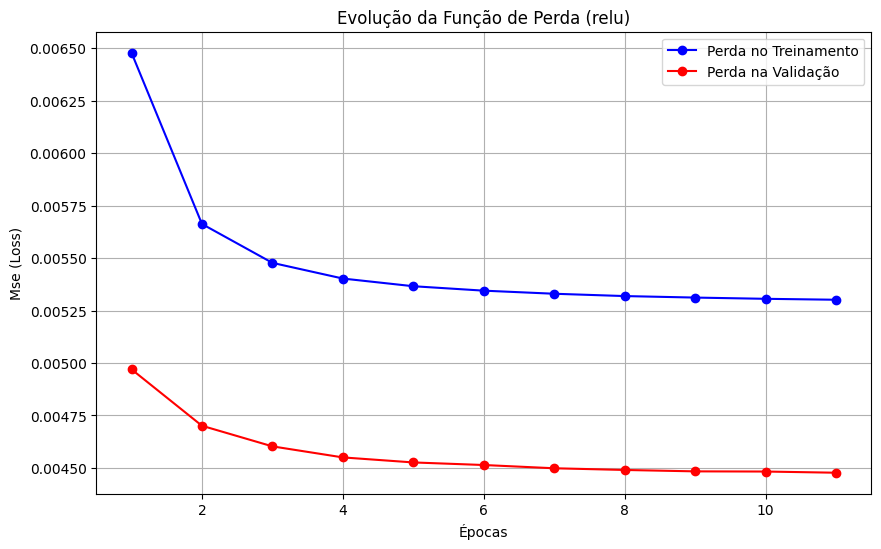

In [26]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, loss, 'bo-', label='Perda no Treinamento')
plt.plot(epochs, val_loss, 'ro-', label='Perda na Validação')

plt.title('Evolução da Função de Perda (relu)')
plt.xlabel('Épocas')
plt.ylabel('Mse (Loss)')
plt.legend()
plt.grid(True)
plt.show()

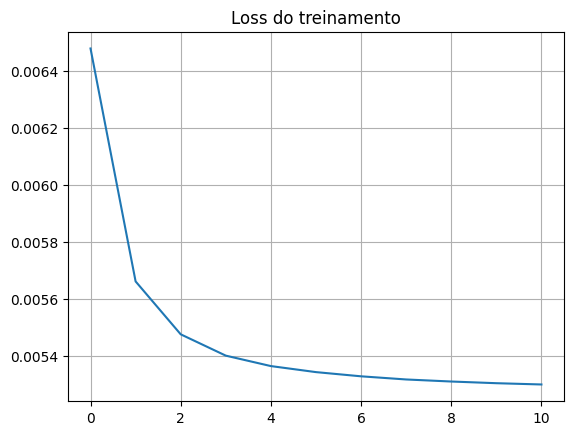

In [27]:
plt.plot(history.history['loss'], label='Training Loss')
plt.title("Loss do treinamento")
plt.grid(True)

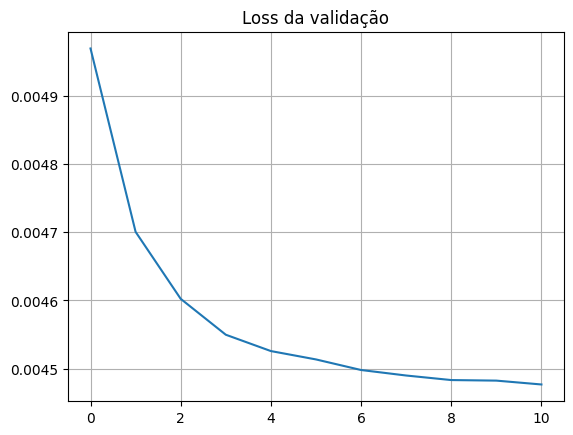

In [28]:
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss da validação")
plt.grid(True)

## Teste Marmousi

In [31]:
n_z, n_x = 751,2301

vp_1d = np.fromfile(r"C:\Users\yuril\.vscode\IC\Marmousi\vp.bin", dtype=np.float32)

expected_size = n_z * n_x

print("AI shape:",(n_z,n_x))
print("VP lido/esperado:", vp_1d.size, expected_size)

vp_depth_full = vp_1d.reshape(n_x, n_z).T.astype(np.float32)

print("VP shape:", vp_depth_full.shape)
#print("AI min/max:", float(n_z, n_x))
print("VP min/max:", float(n_z),float(n_x))

AI shape: (751, 2301)
VP lido/esperado: 1728051 1728051
VP shape: (751, 2301)
VP min/max: 751.0 2301.0


In [32]:
dz = 4

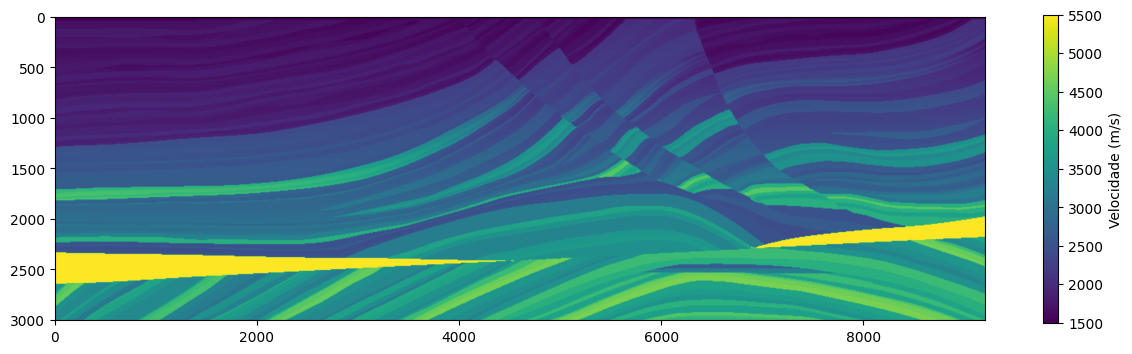

In [33]:
fig, ax = plt.subplots(figsize = (15,10))
plot = ax.imshow(vp_depth_full, extent=[0,n_x*dz,n_z*dz,0])
ax.imshow(vp_depth_full,extent=[0,n_x*dz,n_z*dz,0])

fig.colorbar(plot, ax=ax,shrink = 0.4,label='Velocidade (m/s)')

In [34]:
def dominio_do_tempo(dz,vp,n_x,n_z):

    dt = 2*dz/vp

    t_sum = np.cumsum(dt,0)

    vetor_tempo = np.arange(0,np.max(t_sum),np.max(t_sum)/n_z)
    n_t = len(vetor_tempo)

    tmax_values = []
    twt_cube = np.zeros_like(vp)

    for i in range(n_x):
        vp_coluna = vp[:, i]

        dz_array = np.full_like(vp_coluna, dz)

        vp_valido = np.where(vp_coluna > 0, vp_coluna, np.nan)

        dt1 = dz_array / vp_valido
        twt = 2 * np.nancumsum(dt1)


        twt_cube[:, i] = twt    
        tmax_values.append(twt[-1])

    cubo = twt_cube
    return cubo

In [35]:
cubo = dominio_do_tempo(4,vp_depth_full,n_x,n_z)

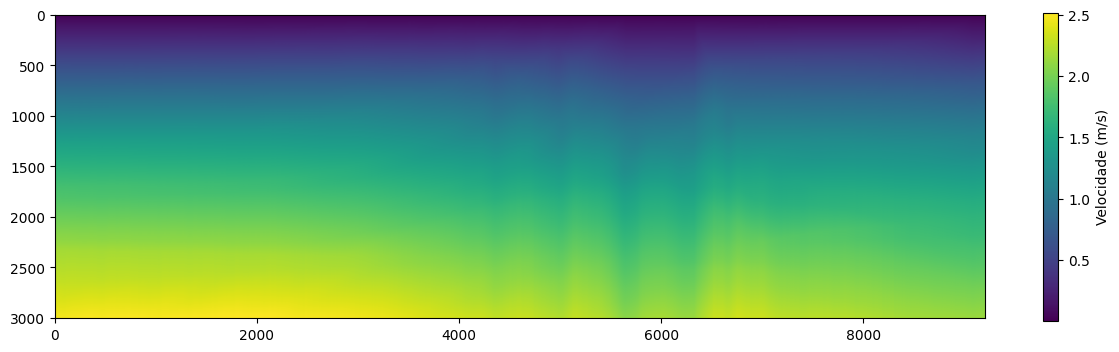

In [36]:
fig, ax = plt.subplots(figsize = (15,10))
plot = ax.imshow(cubo, extent=[0,n_x*dz,n_z*dz,0])
ax.imshow(cubo,extent=[0,n_x*dz,n_z*dz,0])

fig.colorbar(plot, ax=ax,shrink = 0.4,label='Velocidade (m/s)')


In [37]:
den_1d = np.fromfile(r"C:\Users\yuril\.vscode\IC\Marmousi\rho.bin", dtype=np.float32)

densidade = vp_1d.reshape(n_x, n_z).T.astype(np.float32)  


In [38]:
Imp = cubo*densidade
Ref = (Imp[1:,:] - Imp[0:-1,:])/(Imp[1:,:] + Imp[0:-1,:])

In [40]:
Ref = Ref[:512,:]

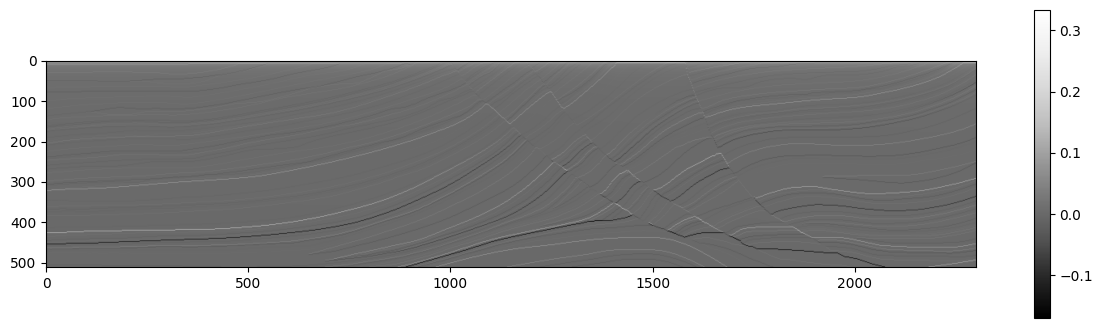

In [41]:
fig, ax = plt.subplots(figsize = (15,10))
plot = ax.imshow(Ref,cmap = "Grays_r")
ax.imshow(Ref,cmap = "Grays_r")

fig.colorbar(plot, ax=ax,shrink = 0.4)

In [42]:
w,t = bruges.filters.ricker(0.064, 0.001, 40)

In [43]:
#traco  = np.array(bruges.filters.convolve(Ref,w))

traco_m = np.array([np.convolve(Ref[:,i],w,mode='same') for i in range(Ref.shape[1])]).T

In [44]:
traco_m = traco_m[:512,:]

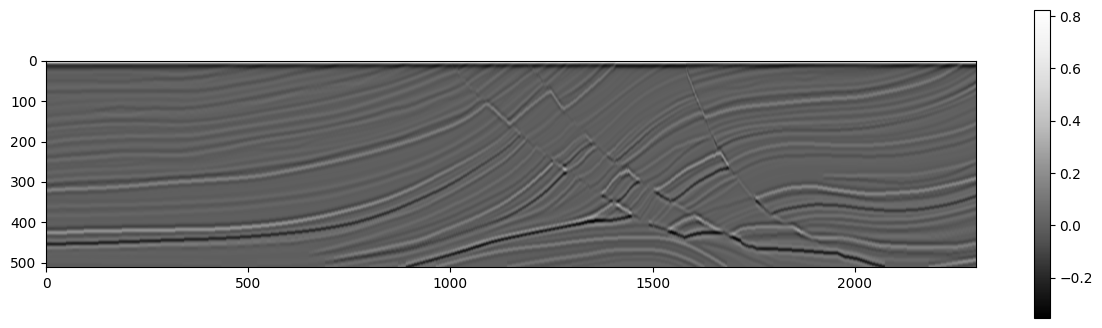

In [45]:
fig, ax = plt.subplots(figsize = (15,10))
plot = ax.imshow(traco_m,cmap = "Grays_r")
plot
fig.colorbar(plot, ax=ax,shrink = 0.4)

In [48]:
predicao_marmousi = model.predict(traco_m)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


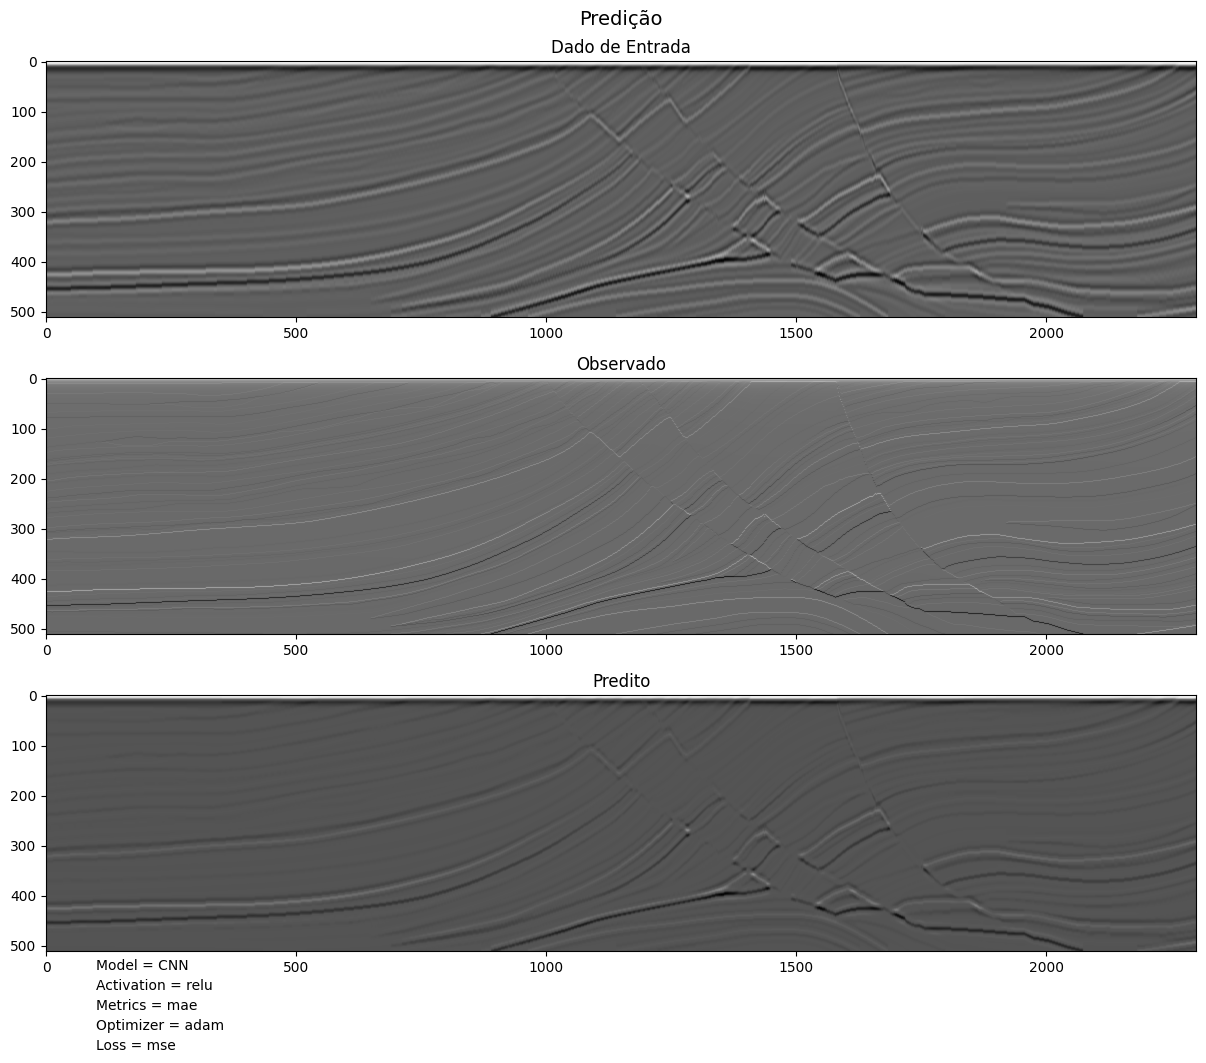

In [49]:
fig, ax = plt.subplots(3,1,figsize = (15,10))
fig.suptitle("Predição",fontsize = 14)
ax[0].imshow(traco_m,cmap = "Grays_r")
ax[0].set_title("Dado de Entrada")

ax[1].imshow(Ref,cmap = "Grays_r")
ax[1].set_title("Observado")

ax[2].imshow(predicao_marmousi,cmap = "Grays_r")
ax[2].set_title("Predito")

fig.text(0.15, 0.02, f'Model = {configs["modelo"]}')
fig.text(0.15, 0.0, f'Activation = {configs["activation"]}')
fig.text(0.15, -0.06, f'Loss = {configs["loss"]}')
fig.text(0.15, -0.02, f'Metrics = {configs["metrics"]}')
fig.text(0.15, -0.04, f'Optimizer = {configs["optimizer"]}')
plt.tight_layout()
